# Seasonal Agriculture Performance Analysis
### VOIS AICTE Data Analytics Internship — Major Project

**Student Name:** [Your Name]
**AICTE STU ID:** [Your ID — check your offer letter]
**College:** [Your College Name]

---

## 1. Introduction

This dataset captures agricultural activity across different **seasons** (Kharif, Rabi, Zaid), regions, and crops in India. It includes environmental conditions (rainfall, temperature, soil quality), farming inputs (fertilizer, irrigation, seeds), and outcomes (yield, cost, revenue, profit).

## 2. Problem Statement

Agricultural performance is influenced by seasonal variation in environmental conditions, farming practices, and resource availability. This raw data does not, on its own, explain **how performance changes across seasons**. This notebook investigates seasonal differences in agricultural performance to uncover meaningful patterns, trends, and relationships.

## 3. Objective

To analyze the dataset and answer:
- How does agricultural performance (yield, profit, cost) vary across seasons?
- Which season is most/least profitable, and why?
- How does irrigation method affect outcomes differently by season?
- What environmental/input factors correlate most strongly with profit?
- Are there significant risks (e.g. disease/pest, loss-making farms) concentrated in specific seasons?


## 4. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)


## 5. Load the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)\n

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

## 6. Data Cleaning & Preparation

### 6.1 Check for Missing Values

In [4]:
df.isnull().sum()[df.isnull().sum() > 0]


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


We found missing values in `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`.
Since these are continuous numeric variables with a relatively small number of missing entries (~1% each),
we fill them with the **median** of each column (robust to outliers).

In [5]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled missing values with median = {median_val:.2f}")

print("\nRemaining nulls:", df.isnull().sum().sum())


Rainfall_mm: filled missing values with median = 582.00
Soil_Moisture_pct: filled missing values with median = 26.40
Yield_Tonnes_Ha: filled missing values with median = 1.74

Remaining nulls: 0


### 6.2 Check for Outliers

Let's look at the extreme values in `Yield_Tonnes_Ha` — a realistic yield rarely exceeds 10-15 tonnes/hectare
even for high-yield crops like sugarcane, so values above 90 look suspicious.

In [6]:
df.nlargest(5, 'Yield_Tonnes_Ha')[['Farm_ID', 'Crop', 'Season', 'Yield_Tonnes_Ha']]


,Farm_ID,Crop,Season,Yield_Tonnes_Ha
1715,SF11716,Sugarcane,Kharif,101.44
3423,SF13424,Sugarcane,Kharif,95.79
3525,SF13526,Sugarcane,Rabi,93.13
1464,SF11465,Sugarcane,Kharif,91.98
3523,SF13524,Sugarcane,Kharif,91.46


These extreme values are almost all **Sugarcane** records — sugarcane genuinely has much higher
yield per hectare than other crops, so these aren't necessarily data errors, but they are still statistical
outliers that would distort season-wise averages. We cap them using the IQR method for cleaner comparisons,
while keeping the original column intact for reference.

In [7]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

n_outliers = (df['Yield_Tonnes_Ha'] > upper_bound).sum()
print(f"Upper bound (IQR method): {upper_bound:.2f} tonnes/ha")
print(f"Number of outliers capped: {n_outliers}")

df['Yield_Tonnes_Ha_capped'] = df['Yield_Tonnes_Ha'].clip(upper=upper_bound)


Upper bound (IQR method): 5.50 tonnes/ha
Number of outliers capped: 302


### 6.3 Quick Sanity Check on Categorical Columns

In [8]:
print("Seasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("Irrigation Methods:", df['Irrigation_Method'].unique())
print("\nRecords per season:")
print(df['Season'].value_counts())


Seasons: ['Kharif', 'Rabi', 'Zaid']
Crops: ['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli', 'Groundnut', 'Sugarcane']
Irrigation Methods: ['Drip', 'Flood', 'Rainfed', 'Sprinkler']

Records per season:
Season
Kharif    1779
Rabi      1627
Zaid       594


## 7. Exploratory Data Analysis — Seasonal Comparison

### 7.1 Overall Seasonal Summary

In [9]:
season_summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha_capped', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
    Loss_Making_Farms_pct=('Profit_INR', lambda x: (x < 0).mean() * 100)
).round(2)

season_summary


,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Cost_INR,Avg_Revenue_INR,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Loss_Making_Farms_pct
Season,,,,,,,,,
Kharif,2.25,178914.65,531804.41,710719.06,849.20,28.45,5.89,54.47,42.21
Rabi,2.03,87689.47,513836.58,601526.05,437.62,23.49,5.19,40.48,51.14
Zaid,1.81,-24804.82,543976.73,519171.90,304.65,31.04,4.41,38.22,64.48


**Observation:** Kharif season shows the highest average profit and lowest share of loss-making farms,
while Zaid season shows a **negative average profit** and the highest proportion of loss-making farms.

### 7.2 Average Profit by Season

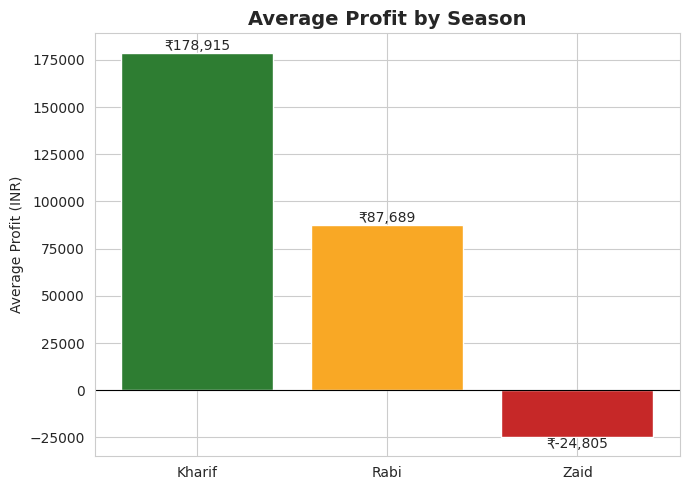

In [10]:
season_order = ['Kharif', 'Rabi', 'Zaid']
colors = {'Kharif': '#2E7D32', 'Rabi': '#F9A825', 'Zaid': '#C62828'}

avg_profit = df.groupby('Season')['Profit_INR'].mean().reindex(season_order)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_profit.index, avg_profit.values, color=[colors[s] for s in season_order])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Profit by Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Profit (INR)')
for bar, val in zip(bars, avg_profit.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'\u20b9{val:,.0f}',
             ha='center', va='bottom' if val >= 0 else 'top', fontsize=10)
plt.tight_layout()
plt.show()


### 7.3 Yield Distribution by Season

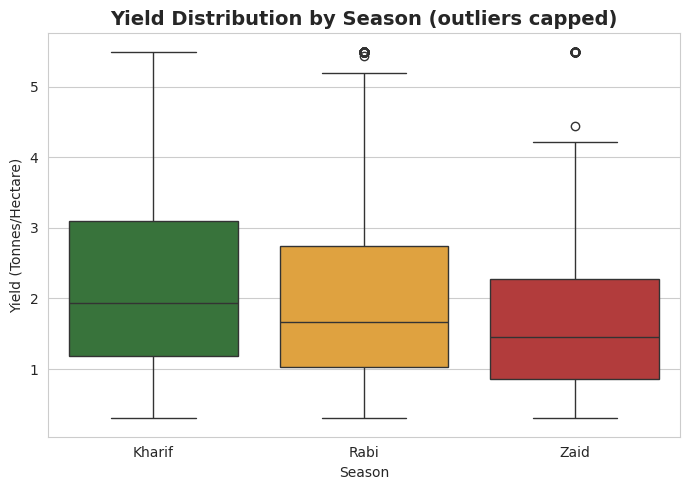

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha_capped', order=season_order,
            hue='Season', palette=colors, legend=False, ax=ax)
ax.set_title('Yield Distribution by Season (outliers capped)', fontsize=14, fontweight='bold')
ax.set_ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()


**Observation:** Median yield decreases slightly from Kharif → Rabi → Zaid, consistent with the profit trend.

### 7.4 Profit by Season and Irrigation Method

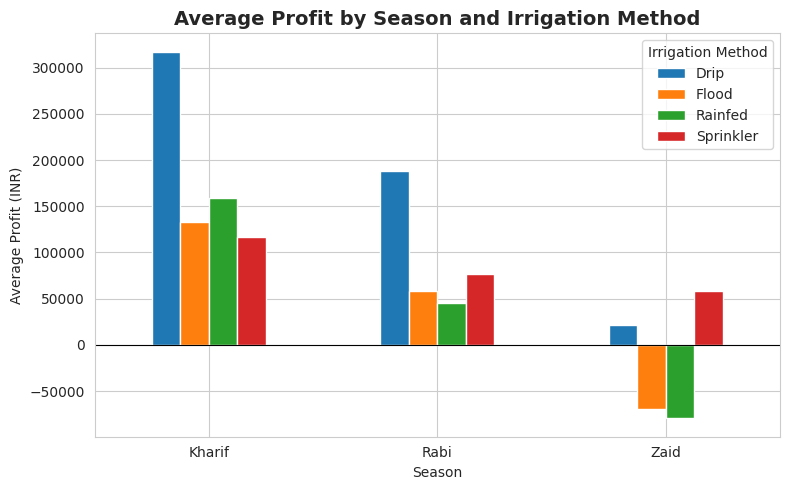

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,317222.0,133374.0,158974.0,116880.0
Rabi,187843.0,58825.0,45232.0,76502.0
Zaid,21292.0,-69787.0,-79467.0,57909.0


In [12]:
pivot = df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().unstack().reindex(season_order)

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Profit by Season and Irrigation Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Profit (INR)')
ax.set_xlabel('Season')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')
plt.tight_layout()
plt.show()

pivot.round(0)


**Key Insight:** **Drip irrigation is the only method that stays profitable across all three seasons**,
including Zaid, where Flood and Rainfed irrigation swing into significant losses. This suggests Drip irrigation
provides resilience against seasonal water stress.

### 7.5 Percentage of Loss-Making Farms by Season

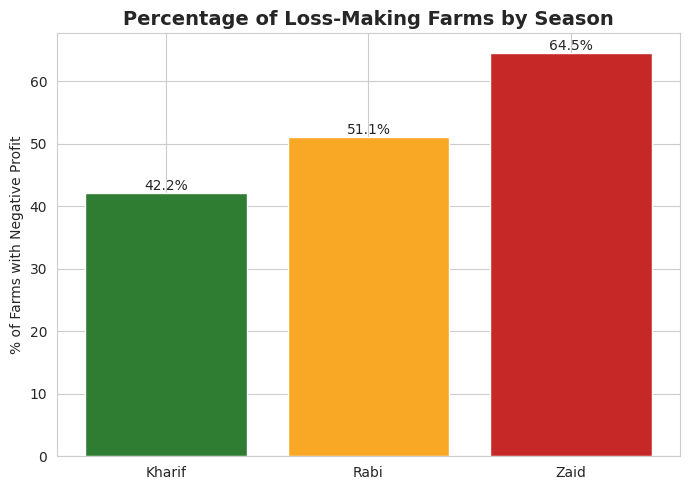

In [13]:
loss_pct = df.groupby('Season')['Profit_INR'].apply(lambda x: (x < 0).mean() * 100).reindex(season_order)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(loss_pct.index, loss_pct.values, color=[colors[s] for s in season_order])
ax.set_title('Percentage of Loss-Making Farms by Season', fontsize=14, fontweight='bold')
ax.set_ylabel('% of Farms with Negative Profit')
for bar, val in zip(bars, loss_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


**Observation:** Nearly **2 out of 3 farms in the Zaid season operate at a loss** — a much higher risk
concentration compared to Kharif (42%) and Rabi (51%).

### 7.6 Water Use Efficiency by Season

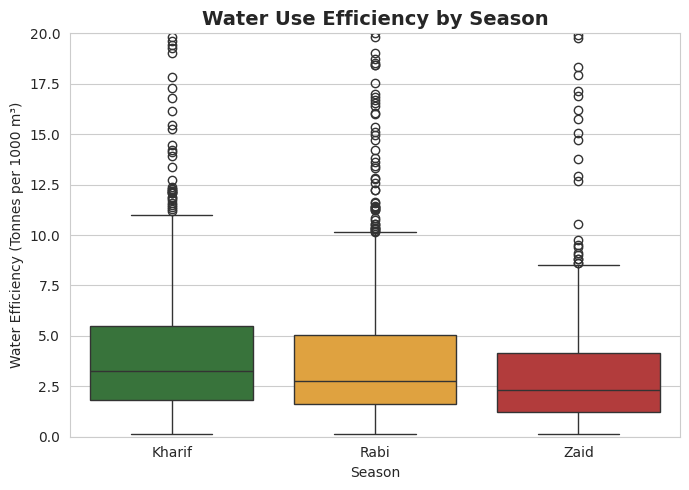

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=season_order,
            hue='Season', palette=colors, legend=False, ax=ax)
ax.set_title('Water Use Efficiency by Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Water Efficiency (Tonnes per 1000 m\u00b3)')
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()


### 7.7 Disease/Pest Risk by Season

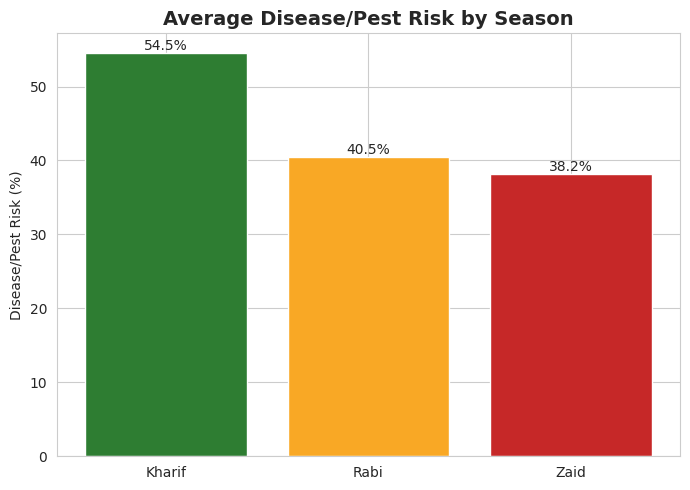

In [15]:
disease = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(season_order)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(disease.index, disease.values, color=[colors[s] for s in season_order])
ax.set_title('Average Disease/Pest Risk by Season', fontsize=14, fontweight='bold')
ax.set_ylabel('Disease/Pest Risk (%)')
for bar, val in zip(bars, disease.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


**Observation:** Interestingly, disease/pest risk is *highest* in Kharif (54%) despite Kharif also
being the most profitable season — suggesting farmers in Kharif may be managing risk effectively through other
means (e.g. irrigation choice, better resource allocation).

### 7.8 Correlation Between Environmental Factors and Profit

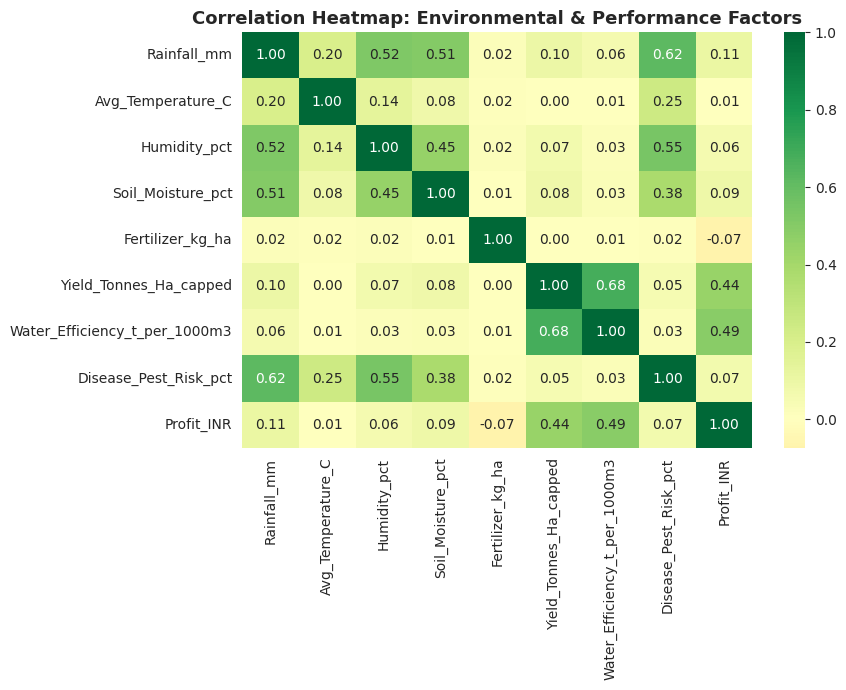

In [16]:
key_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
            'Fertilizer_kg_ha', 'Yield_Tonnes_Ha_capped', 'Water_Efficiency_t_per_1000m3',
            'Disease_Pest_Risk_pct', 'Profit_INR']

corr_matrix = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Correlation Heatmap: Environmental & Performance Factors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** `Yield` and `Water_Efficiency` show the strongest positive correlation with `Profit`
among the factors examined, while `Fertilizer_kg_ha` shows a very weak/near-zero relationship — suggesting
that simply increasing fertilizer use does not reliably translate into higher profit.

### 7.9 Yield by Season and Crop

In [17]:
crop_season_yield = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha_capped'].mean().unstack().reindex(season_order)
crop_season_yield.round(2)


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.73,1.37,1.48,2.96,1.04,2.70,5.43,2.25
Rabi,1.47,1.20,1.23,2.60,0.88,2.32,5.38,2.06
Zaid,1.20,0.96,1.04,2.29,0.67,1.90,5.42,1.75


**Observation:** Yield for every crop declines consistently from Kharif → Rabi → Zaid,
confirming that the seasonal effect applies broadly across crop types rather than being driven by
just one or two crops.

## 8. Key Findings Summary

1. **Kharif is the most profitable and highest-yielding season** on average, while **Zaid is loss-making
   on average**, with 64% of Zaid farms reporting negative profit.
2. **Drip irrigation is the most resilient method across all seasons** — it remains profitable in Zaid
   while Flood and Rainfed irrigation turn negative.
3. **Water efficiency and yield are the strongest positive drivers of profit**; fertilizer usage shows
   negligible correlation with profitability, suggesting diminishing or no returns from over-fertilization.
4. **Disease/pest risk is highest in Kharif**, yet Kharif remains the most profitable season — indicating
   that favorable environmental conditions (rainfall, temperature) may outweigh the elevated risk.
5. **The seasonal yield decline is consistent across all 8 crop types**, confirming this is a genuine
   seasonal effect rather than a crop-specific anomaly.

## 9. Recommendations

- **Prioritize Drip irrigation, especially for Zaid season crops**, where water stress most severely
  impacts profitability.
- **Re-evaluate fertilizer application strategy** — current usage levels show little correlation with
  profit, and reducing excess fertilizer could cut costs without hurting yield.
- **Target interventions at Zaid-season farms** (e.g. subsidized irrigation upgrades, crop insurance,
  or shifting to less water-intensive crops) given their high loss rate.
- **Further investigate Kharif's high disease/pest risk** despite strong profitability — proactive pest
  management could push profits even higher.

## 10. Conclusion

This analysis confirms that agricultural performance varies meaningfully across seasons — driven not just
by weather, but by *how* farms respond to seasonal conditions (particularly irrigation choice). Kharif
emerges as the strongest season overall, while Zaid represents the highest financial risk. These findings
can support more targeted, season-aware agricultural planning and resource allocation.
